---
date: '2026-03-12T20:00:07+08:00'
title: 'Using Pandas For Getting Data And Analise Them'
feature_link: "https://www.midjourney.com/home/"
feature_text: "by IA Midjourney"
description: 'Using Pandas For Getting Data And Analise Them'
isStarred: false
tags:
- pandas
categories:
- dev
images:
keywords:
series:
- Data and Data Tools
draft: true
---

## The idea

I want to test some of the pandas functionality so I try the import from HTML table for make some data analisys.
So I choose a web page with data in a table (or two in this case)

In [1]:
import matplotlib
import pandas as pd


Here we have the basic import for the needed package for the project.

In [2]:
url = "https://www.mangacodex.com/oricon_yearly.php?title_series=&year_series=All&title_volumes=&year_volumes=All"

pd.set_option("display.precision", 2)

Some basic config (the log, the url,...) for my little script. I allwayse put at the top of the file for easy edit of them, if needed.

In [3]:
print("Downloading data from the page...")
tables = pd.read_html(url, thousands='.', decimal =',')
print(f"Found {len(tables)} tables on the page.")

df1 = pd.DataFrame(tables[0])
print(type(df1))
df2 = pd.DataFrame(tables[1])
print(type(df2))

Found 2 tables on the page.
<class 'pandas.DataFrame'>
<class 'pandas.DataFrame'>


Starting with the scrape of the page with Pandas. In this case it returnes 2 table in pandas.DataFrame

In [4]:
if len(tables) >= 2:
    table_series = tables[0]
    table_volumes = tables[1]

else:
    print("Error: The page does not contain enough tables.")
    raise Error

And now we have the two table as pandas Dataframe. Are there some empty data?

In [5]:
print("-*-" * 20)
print("Missing value stats for Series:")
print(table_series.isnull().sum())
print()
print("-*-" * 20)
print("Missing value stats for Volumes:")
print(table_volumes.isnull().sum())

-*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*-
Missing value stats for Series:
Ranking    0
Title      0
Sales      0
Year       0
dtype: int64

-*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*-
Missing value stats for Volumes:
Ranking    0
Volume     0
Sales      0
Year       0
dtype: int64


## Start the analysis

So we know the data is consistant so we need to know some generic data about this two dataset.

In [11]:
print("-*-")
print(table_series.head())
print(table_series.info(verbose=False))
print()
print("-*-")
print(table_volumes.head())
print(table_volumes.info(verbose=False))


-*-
   Ranking          Title    Sales  Year
0        1  One Piece #50  1678208  2008
1        2  One Piece #51  1646978  2008
2        3       Nana #19  1645128  2008
3        4  One Piece #49  1544000  2008
4        5       Nana #20  1431335  2008
<class 'pandas.DataFrame'>
RangeIndex: 3413 entries, 0 to 3412
Columns: 4 entries, Ranking to Year
dtypes: int64(3), str(1)
memory usage: 106.8 KB
None

-*-
   Ranking             Volume    Sales  Year
0        1          One Piece  5956540  2008
1        2             Naruto  4261054  2008
2        3  20th Century Boys  3710054  2008
3        4     Hitman Reborn!  3371618  2008
4        5             Bleach  3161825  2008
<class 'pandas.DataFrame'>
RangeIndex: 860 entries, 0 to 859
Columns: 4 entries, Ranking to Year
dtypes: int64(3), str(1)
memory usage: 27.0 KB
None


<Axes: title={'center': 'Manga Series'}>

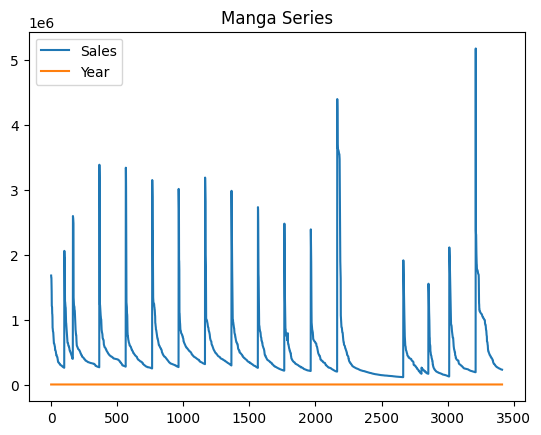

In [12]:
table_series[["Title","Sales","Year"]].plot(title="Manga Series")